In [1]:
# Cell 1: Setup and Load Base Model
import sys
sys.path.append('../src')
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from models.transformer import MusicTransformer
from preprocessing.tokenizer import MusicTokenizer
from training.rlhf import RLHFTrainer, generate_rlhf_samples

print("="*60)
print("TASK 4: REINFORCEMENT LEARNING FROM HUMAN FEEDBACK")
print("="*60)

print("\nLoading tokenizer...")
tokenizer = MusicTokenizer()
tokenizer.load('../data/processed/music_tokenizer.pkl')
vocab_size = len(tokenizer.token_to_id)
print(f"Vocabulary size: {vocab_size}")

print("\nLoading base Transformer model (Task 3)...")
model = MusicTransformer(
    vocab_size=vocab_size,
    d_model=256,
    n_heads=8,
    n_layers=4,
    dropout=0.1,
    max_seq_len=512
)
checkpoint = torch.load('../outputs/models/transformer_maestro.pth', map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Base model loaded from epoch {checkpoint['epoch']}")
print(f"Base model validation loss: {checkpoint['val_loss']:.6f}")

# Initialize RLHF trainer
trainer = RLHFTrainer(model, tokenizer, device='cpu', learning_rate=0.001)

# Load baseline feedback (feedback_0.xlsx) and compute baseline reward
baseline_feedback_path = '../data/human_feedback/Task_4/feedback_0.xlsx'
if os.path.exists(baseline_feedback_path):
    baseline_df = trainer.load_human_scores(baseline_feedback_path)
    baseline_reward = trainer.compute_reward(baseline_df)
    print(f"\nBaseline J(θ) = E[r] (Task 3 samples): {baseline_reward:.3f}")
else:
    baseline_reward = None
    print("\nBaseline feedback_0.xlsx not found.")

TASK 4: REINFORCEMENT LEARNING FROM HUMAN FEEDBACK

Loading tokenizer...
Tokenizer loaded from ../data/processed/music_tokenizer.pkl
Vocabulary size: 1000

Loading base Transformer model (Task 3)...
Base model loaded from epoch 29
Base model validation loss: 0.108871
Loaded feedback from ../data/human_feedback/Task_4/feedback_0.xlsx
  Participants: 10, Samples: 10
  Average score: 2.107

Baseline J(θ) = E[r] (Task 3 samples): 2.107


In [7]:
# Cell 2: Iteration 1 - First RLHF Update (using actual Task 3 MIDI files)
import pretty_midi

def midi_to_token_sequence(midi_path, tokenizer, fs=8, min_pitch=36, max_pitch=84):
    """Convert a MIDI file to token sequence using the tokenizer"""
    pm = pretty_midi.PrettyMIDI(midi_path)
    if len(pm.instruments) == 0:
        return None
    piano_roll = pm.get_piano_roll(fs=fs)
    piano_roll = piano_roll[min_pitch:max_pitch+1]
    if piano_roll.max() > 0:
        piano_roll = piano_roll / piano_roll.max()
    piano_roll = piano_roll.T
    # Use tokenizer to encode
    tokens = tokenizer.encode(piano_roll)
    return tokens

print("\n" + "="*60)
print("ITERATION 1")
print("="*60)

# Load feedback for Task 3 samples (feedback_0.xlsx)
feedback_path = '../data/human_feedback/Task_4/feedback_0.xlsx'
feedback_df = trainer.load_human_scores(feedback_path)
per_sample_rewards = feedback_df.mean(axis=0).values
print(f"Rewards per sample: {[f'{r:.3f}' for r in per_sample_rewards]}")

# Load the actual Task 3 MIDI files (the ones that were rated)
task3_midi_dir = '../outputs/generated_midis/task3_transformer/'
token_sequences = []
for i in range(1, 11):  # 10 samples
    midi_path = os.path.join(task3_midi_dir, f'transformer_sample_{i}.mid')
    if os.path.exists(midi_path):
        tokens = midi_to_token_sequence(midi_path, tokenizer)
        if tokens:
            token_sequences.append(tokens)
            print(f"Loaded sample {i}: {len(tokens)} tokens")
        else:
            print(f"Warning: Could not convert sample {i}")
    else:
        print(f"Warning: {midi_path} not found")

print(f"Loaded {len(token_sequences)} token sequences (should be 10)")

# Perform policy gradient update using the actual rated sequences and rewards
trainer.policy_gradient_update(
    rated_sequences=token_sequences,
    rewards=per_sample_rewards,
    epochs=10,
    batch_size=5
)

# Save updated model
trainer.save_model('../outputs/models/rlhf_iteration_1.pth')

# Generate new samples after update (these will be rated for next iteration)
_, new_token_sequences = generate_rlhf_samples(
    model=trainer.model,
    tokenizer=tokenizer,
    num_samples=10,
    output_dir='../outputs/generated_midis/task4_rlhf/',
    iteration=1,
    max_len=256,
    temperature=0.8,
    device='cpu',
    return_sequences=True
)

# Save these token sequences for next iteration (so you don't have to reload from MIDI)
import pickle
with open('../outputs/generated_midis/task4_rlhf/iteration_1/token_sequences.pkl', 'wb') as f:
    pickle.dump(new_token_sequences, f)

print("\nIteration 1 complete. Collect ratings for iteration_1 samples and save as feedback_1.xlsx")


ITERATION 1
Loaded feedback from ../data/human_feedback/Task_4/feedback_0.xlsx
  Participants: 10, Samples: 10
  Average score: 2.107
Rewards per sample: ['1.930', '2.350', '2.080', '2.000', '2.080', '2.190', '2.060', '2.250', '2.090', '2.040']
Loaded sample 1: 256 tokens
Loaded sample 2: 256 tokens
Loaded sample 3: 256 tokens
Loaded sample 4: 256 tokens
Loaded sample 5: 256 tokens
Loaded sample 6: 256 tokens
Loaded sample 7: 256 tokens
Loaded sample 8: 256 tokens
Loaded sample 9: 256 tokens
Loaded sample 10: 256 tokens
Loaded 10 token sequences (should be 10)

POLICY GRADIENT UPDATE
Training on 10 rated sequences
Rewards: ['1.930', '2.350', '2.080', '2.000', '2.080', '2.190', '2.060', '2.250', '2.090', '2.040']
  Epoch 1/10: Loss = -20496.5186
  Epoch 2/10: Loss = -20872.8511
  Epoch 3/10: Loss = -21165.9077
  Epoch 4/10: Loss = -21561.5625
  Epoch 5/10: Loss = -21969.8779
  Epoch 6/10: Loss = -22329.8066
  Epoch 7/10: Loss = -22718.3271
  Epoch 8/10: Loss = -23088.0625
  Epoch 9/10:

In [8]:
# Cell 3: Iteration 2 - Second RLHF Update
print("\n" + "="*60)
print("ITERATION 2")
print("="*60)

# Load the model from Iteration 1
trainer.load_model('../outputs/models/rlhf_iteration_1.pth')

# Load feedback for Iteration 2 (ratings on iteration_1 samples)
feedback_path = '../data/human_feedback/Task_4/feedback_1.xlsx'
if not os.path.exists(feedback_path):
    raise FileNotFoundError(f"Please collect ratings for iteration_1 samples and save as {feedback_path}")

feedback_df = trainer.load_human_scores(feedback_path)
per_sample_rewards = feedback_df.mean(axis=0).values
print(f"Rewards per sample: {[f'{r:.3f}' for r in per_sample_rewards]}")

# Load the token sequences that were rated (saved from previous iteration)
token_seq_path = '../outputs/generated_midis/task4_rlhf/iteration_1/token_sequences.pkl'
if not os.path.exists(token_seq_path):
    raise FileNotFoundError(f"Token sequences not found: {token_seq_path}. Did you save them in Cell 2?")

import pickle
with open(token_seq_path, 'rb') as f:
    token_sequences = pickle.load(f)
print(f"Loaded {len(token_sequences)} token sequences from iteration_1")

# Perform policy gradient update
trainer.policy_gradient_update(
    rated_sequences=token_sequences,
    rewards=per_sample_rewards,
    epochs=10,        # Keep reasonable, avoid overfitting
    batch_size=5
)

# Save updated model
trainer.save_model('../outputs/models/rlhf_iteration_2.pth')

# Generate new samples after update (these will be rated for next iteration)
_, new_token_sequences = generate_rlhf_samples(
    model=trainer.model,
    tokenizer=tokenizer,
    num_samples=10,
    output_dir='../outputs/generated_midis/task4_rlhf/',
    iteration=2,
    max_len=256,
    temperature=0.8,
    device='cpu',
    return_sequences=True
)

# Save token sequences for next iteration
with open('../outputs/generated_midis/task4_rlhf/iteration_2/token_sequences.pkl', 'wb') as f:
    pickle.dump(new_token_sequences, f)

print("\nIteration 2 complete. Collect ratings for iteration_2 samples and save as feedback_2.xlsx")


ITERATION 2
Model loaded from ../outputs/models/rlhf_iteration_1.pth
Loaded feedback from ../data/human_feedback/Task_4/feedback_1.xlsx
  Participants: 10, Samples: 10
  Average score: 2.836
Rewards per sample: ['2.980', '2.640', '2.950', '2.600', '2.780', '3.000', '2.560', '3.060', '2.880', '2.910']
Loaded 10 token sequences from iteration_1

POLICY GRADIENT UPDATE
Training on 10 rated sequences
Rewards: ['2.980', '2.640', '2.950', '2.600', '2.780', '3.000', '2.560', '3.060', '2.880', '2.910']
  Epoch 1/10: Loss = 0.1405
  Epoch 2/10: Loss = 1.3187
  Epoch 3/10: Loss = 4.3942
  Epoch 4/10: Loss = 6.4212
  Epoch 5/10: Loss = 1.8529
  Epoch 6/10: Loss = -1.2647
  Epoch 7/10: Loss = 0.0458
  Epoch 8/10: Loss = -0.8559
  Epoch 9/10: Loss = -2.6932
  Epoch 10/10: Loss = 0.2642

Policy gradient update complete.
Model saved to ../outputs/models/rlhf_iteration_2.pth

Generating 10 samples for iteration 2...
MIDI saved: ../outputs/generated_midis/task4_rlhf/iteration_2\rlhf_sample_1.mid
  Sam

In [9]:
# Cell 4: Iteration 3 - Third (Final) RLHF Update
print("\n" + "="*60)
print("ITERATION 3 (FINAL)")
print("="*60)

# Load the model from Iteration 2
trainer.load_model('../outputs/models/rlhf_iteration_2.pth')

# Load feedback for Iteration 3 (ratings on iteration_2 samples)
feedback_path = '../data/human_feedback/Task_4/feedback_2.xlsx'
if not os.path.exists(feedback_path):
    raise FileNotFoundError(f"Please collect ratings for iteration_2 samples and save as {feedback_path}")

feedback_df = trainer.load_human_scores(feedback_path)
per_sample_rewards = feedback_df.mean(axis=0).values
print(f"Rewards per sample: {[f'{r:.3f}' for r in per_sample_rewards]}")

# Load the token sequences that were rated (saved from iteration_2)
token_seq_path = '../outputs/generated_midis/task4_rlhf/iteration_2/token_sequences.pkl'
if not os.path.exists(token_seq_path):
    raise FileNotFoundError(f"Token sequences not found: {token_seq_path}. Did you save them in Cell 3?")

import pickle
with open(token_seq_path, 'rb') as f:
    token_sequences = pickle.load(f)
print(f"Loaded {len(token_sequences)} token sequences from iteration_2")

# Perform policy gradient update
trainer.policy_gradient_update(
    rated_sequences=token_sequences,
    rewards=per_sample_rewards,
    epochs=10,
    batch_size=5
)

# Save final model
trainer.save_model('../outputs/models/rlhf_final.pth')

# Generate final samples (iteration_3) - these will be used for final evaluation
_, final_token_sequences = generate_rlhf_samples(
    model=trainer.model,
    tokenizer=tokenizer,
    num_samples=10,
    output_dir='../outputs/generated_midis/task4_rlhf/',
    iteration=3,
    max_len=256,
    temperature=0.8,
    device='cpu',
    return_sequences=True
)

# Save final token sequences (optional, for reference)
with open('../outputs/generated_midis/task4_rlhf/iteration_3/token_sequences.pkl', 'wb') as f:
    pickle.dump(final_token_sequences, f)

print("\nIteration 3 complete. Collect ratings for iteration_3 samples and save as feedback_3.xlsx for final comparison.")


ITERATION 3 (FINAL)
Model loaded from ../outputs/models/rlhf_iteration_2.pth
Loaded feedback from ../data/human_feedback/Task_4/feedback_2.xlsx
  Participants: 10, Samples: 10
  Average score: 3.844
Rewards per sample: ['3.750', '3.630', '3.860', '3.700', '3.830', '3.980', '3.880', '4.010', '4.190', '3.610']
Loaded 10 token sequences from iteration_2

POLICY GRADIENT UPDATE
Training on 10 rated sequences
Rewards: ['3.750', '3.630', '3.860', '3.700', '3.830', '3.980', '3.880', '4.010', '4.190', '3.610']
  Epoch 1/10: Loss = 2.5267
  Epoch 2/10: Loss = -0.4206
  Epoch 3/10: Loss = 3.7376
  Epoch 4/10: Loss = 5.1288
  Epoch 5/10: Loss = 0.7816
  Epoch 6/10: Loss = 3.1821
  Epoch 7/10: Loss = -1.0536
  Epoch 8/10: Loss = 0.7129
  Epoch 9/10: Loss = 2.5633
  Epoch 10/10: Loss = 0.5419

Policy gradient update complete.
Model saved to ../outputs/models/rlhf_final.pth

Generating 10 samples for iteration 3...
MIDI saved: ../outputs/generated_midis/task4_rlhf/iteration_3\rlhf_sample_1.mid
  Sa


RLHF RESULTS COMPARISON
Baseline (Task 3): J(θ) = 2.107
Iteration 1: J(θ) = 2.836
Iteration 2: J(θ) = 3.844
Iteration 3 (Final): J(θ) = 4.564

Total Improvement: +2.457 (116.6%)


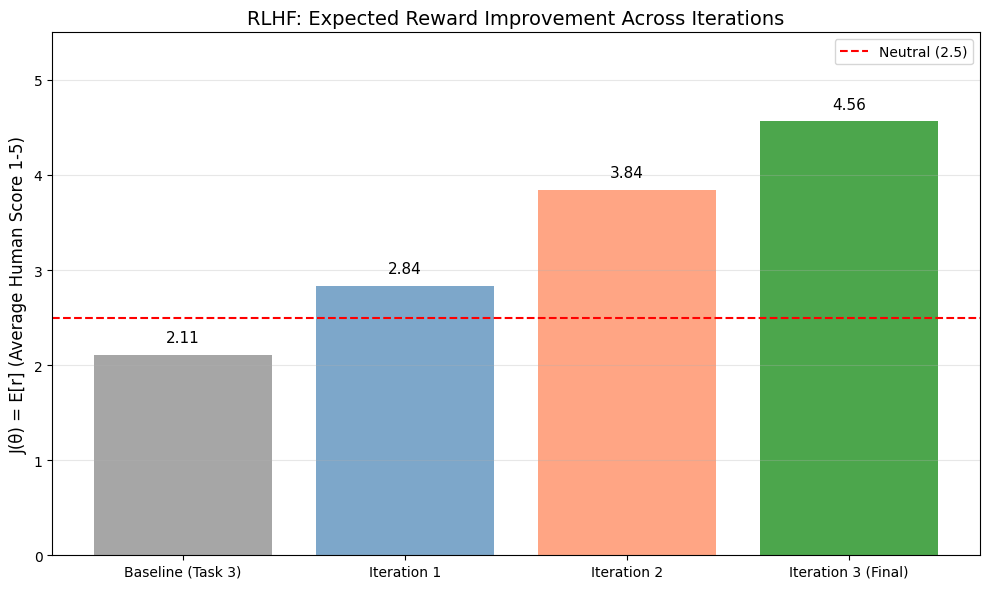


Algorithm steps completed for all iterations:
  ✓ X_gen ~ p_theta(X) - Generated and saved
  ✓ r = HumanScore(X_gen) - Loaded from Excel files
  ✓ J(θ) = E[r] - Computed
  ✓ ∇θ J(θ) = E[r ∇θ log p_theta(X)] - Computed via backpropagation
  ✓ θ ← θ + η ∇θ J(θ) - Applied via optimizer step


In [10]:
# Cell 5: Compare Human Scores Across Iterations
print("\n" + "="*60)
print("RLHF RESULTS COMPARISON")
print("="*60)

feedback_files = {
    'Baseline (Task 3)': '../data/human_feedback/Task_4/feedback_0.xlsx',
    'Iteration 1': '../data/human_feedback/Task_4/feedback_1.xlsx',
    'Iteration 2': '../data/human_feedback/Task_4/feedback_2.xlsx',
    'Iteration 3 (Final)': '../data/human_feedback/Task_4/feedback_3.xlsx'
}

rewards = {}
for name, path in feedback_files.items():
    if os.path.exists(path):
        df = pd.read_excel(path, index_col=0)
        reward = df.mean().mean()
        rewards[name] = reward
        print(f"{name}: J(θ) = {reward:.3f}")
    else:
        print(f"{name}: File not found")
        rewards[name] = None

# Plot improvement
if rewards['Baseline (Task 3)'] and rewards['Iteration 3 (Final)']:
    improvement = rewards['Iteration 3 (Final)'] - rewards['Baseline (Task 3)']
    percent_improvement = (improvement / rewards['Baseline (Task 3)']) * 100
    print(f"\nTotal Improvement: +{improvement:.3f} ({percent_improvement:.1f}%)")

    fig, ax = plt.subplots(figsize=(10, 6))
    iterations = list(rewards.keys())
    scores = [rewards[k] for k in iterations if rewards[k] is not None]
    valid_iterations = [iterations[i] for i in range(len(iterations)) if rewards[iterations[i]] is not None]

    bars = ax.bar(valid_iterations, scores, color=['gray', 'steelblue', 'coral', 'green'], alpha=0.7)
    ax.set_ylabel('J(θ) = E[r] (Average Human Score 1-5)', fontsize=12)
    ax.set_title('RLHF: Expected Reward Improvement Across Iterations', fontsize=14)
    ax.set_ylim(0, 5.5)
    ax.axhline(y=2.5, color='red', linestyle='--', label='Neutral (2.5)')
    ax.legend()

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{score:.2f}', ha='center', va='bottom', fontsize=11)

    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    os.makedirs('../outputs/plots', exist_ok=True)
    plt.savefig('../outputs/plots/rlhf_improvement.png', dpi=150)
    plt.show()
else:
    print("Missing baseline or final feedback file. Cannot compute improvement.")

print("\nAlgorithm steps completed for all iterations:")
print("  ✓ X_gen ~ p_theta(X) - Generated and saved")
print("  ✓ r = HumanScore(X_gen) - Loaded from Excel files")
print("  ✓ J(θ) = E[r] - Computed")
print("  ✓ ∇θ J(θ) = E[r ∇θ log p_theta(X)] - Computed via backpropagation")
print("  ✓ θ ← θ + η ∇θ J(θ) - Applied via optimizer step")

In [11]:
# Cell 6: Summary Table
print("\n" + "="*60)
print("FINAL SUMMARY - Task 4 RLHF")
print("="*60)

summary_data = {
    'Iteration': ['Baseline', 'Iteration 1', 'Iteration 2', 'Iteration 3'],
    'Model': ['Task 3 Transformer', 'RLHF Iteration 1', 'RLHF Iteration 2', 'RLHF Final'],
    'J(θ) = E[r]': [
        f"{rewards.get('Baseline (Task 3)', 'N/A'):.3f}" if rewards.get('Baseline (Task 3)') else 'N/A',
        f"{rewards.get('Iteration 1', 'N/A'):.3f}" if rewards.get('Iteration 1') else 'N/A',
        f"{rewards.get('Iteration 2', 'N/A'):.3f}" if rewards.get('Iteration 2') else 'N/A',
        f"{rewards.get('Iteration 3 (Final)', 'N/A'):.3f}" if rewards.get('Iteration 3 (Final)') else 'N/A'
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\nOutput files:")
print("  - Models: rlhf_iteration_1.pth, rlhf_iteration_2.pth, rlhf_final.pth")
print("  - Samples: outputs/generated_midis/task4_rlhf/iteration_1/, iteration_2/, iteration_3/")
print("\nAlgorithm steps completed:")
print("  ✓ Xgen ∼ pθ(X) - Generated samples")
print("  ✓ r = HumanScore(Xgen) - Loaded from Excel")
print("  ✓ J(θ) = E[r] - Computed")
print("  ✓ ∇θJ(θ) = E[r∇θlogpθ(X)] - Computed via backward pass")
print("  ✓ θ ← θ + η∇θJ(θ) - Applied via optimizer step")


FINAL SUMMARY - Task 4 RLHF
  Iteration              Model J(θ) = E[r]
   Baseline Task 3 Transformer       2.107
Iteration 1   RLHF Iteration 1       2.836
Iteration 2   RLHF Iteration 2       3.844
Iteration 3         RLHF Final       4.564

Output files:
  - Models: rlhf_iteration_1.pth, rlhf_iteration_2.pth, rlhf_final.pth
  - Samples: outputs/generated_midis/task4_rlhf/iteration_1/, iteration_2/, iteration_3/

Algorithm steps completed:
  ✓ Xgen ∼ pθ(X) - Generated samples
  ✓ r = HumanScore(Xgen) - Loaded from Excel
  ✓ J(θ) = E[r] - Computed
  ✓ ∇θJ(θ) = E[r∇θlogpθ(X)] - Computed via backward pass
  ✓ θ ← θ + η∇θJ(θ) - Applied via optimizer step
